<a href="https://colab.research.google.com/github/deorebhumika06/ai-projects/blob/main/Hotel-Booking-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Hotel Booking Analysis Project
  ## Introduction

This project analyzes hotel booking data to understand customer behavior, booking patterns, and cancellation trends. The goal is to extract useful insights that can help improve hotel business decisions.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [9]:
df=pd.read_csv('/content/hotel_booking.csv.zip')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## Data Cleaning

- Removed missing values from important columns like country
- Removed duplicate records
- Cleaned data for better analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
df['reservation_status_date']=pd.to_datetime(df['reservation_status_date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

In [6]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [7]:
df.drop(['agent','company'],axis=1,inplace=True)
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [10]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,name,email,phone-number,credit_card
count,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898
unique,2,12,5,177,7,5,10,12,3,4,3,81234,115425,118898,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,Robert Smith,Michael.C@gmail.com,422-804-6403,************3627
freq,79302,13852,91863,48586,56402,97730,85601,73863,104163,89174,74745,48,6,1,28


In [12]:
for col in df.describe(include='object').columns:
  print(col)
  print(df[col].unique())
  print('_'*50)

hotel
['Resort Hotel' 'City Hotel']
__________________________________________________
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
__________________________________________________
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
__________________________________________________
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' 'ROU' 'NOR' 'OMN' 'ARG' 'POL' 'DEU'
 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST' 'CZE'
 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR' 'UKR'
 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO' 'ISR'
 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM' 'HRV'
 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY' 'KWT'
 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN' 'SYC'
 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB' 'CMR'
 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 

In [13]:
import re

In [14]:
def extract_cancel(is_canceled):
  extract_no=re.findall('[0-9]+',str(is_canceled))
  if len(extract_no)>0:
    return int(extract_no[0])
  else:
    return None
df['is_canceled']=df['is_canceled'].apply(extract_cancel)

In [16]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## Exploratory Data Analysis

In [40]:

cancel_count = df['is_canceled'].value_counts()
print(cancel_count)
df['market_segment'].value_counts(normalize=True)
cancel = df[df['is_canceled'] == 1]
cancel['market_segment'].value_counts()

is_canceled
0    74745
1    44153
Name: count, dtype: int64


,count
market_segment,
Online TA,20738
Groups,12097
Offline TA/TO,8278
Direct,1920
Corporate,978
Complementary,90
Aviation,52


### Cancellation Analysis for Resort Hotel

In [41]:
Resort_Hotel=df[df['hotel'] == 'Resort Hotel']
Resort_Hotel['is_canceled'].value_counts()

,count
is_canceled,
0,28519
1,11077


### Cancellation Analysis for city Hotel

In [42]:
City_Hotel=df[df['hotel'] == 'City Hotel']
City_Hotel['is_canceled'].value_counts()

,count
is_canceled,
0,46226
1,33076


### Average Daily Rate (ADR) Trend for Resort Hotel

In [43]:
Resort_Hotel=df[df['hotel'] == 'Resort Hotel']
Resort_Hotel=Resort_Hotel.groupby('reservation_status_date')['adr'].mean()

Average Daily Rate (ADR) Trend for city Hotel

In [44]:
City_hotel=df[df['hotel'] == 'City Hotel']
City_hotel=City_hotel.groupby('reservation_status_date')['adr'].mean()

## Visualization

Cancellation Bar Chart

is_canceled
0    74745
1    44153
Name: count, dtype: int64


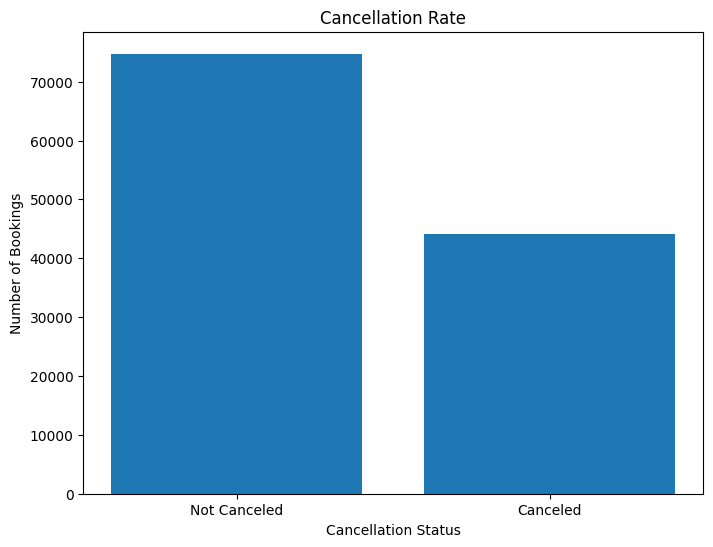

In [23]:
cancel_count=df['is_canceled'].value_counts()
print(cancel_count)
plt.figure(figsize=(8,6))
plt.title('Cancellation Rate')
plt.bar(cancel_count.index, cancel_count.values)
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.xlabel('Cancellation Status')
plt.ylabel('Number of Bookings')
plt.show()

### Cancellation Rate by Hotel Type

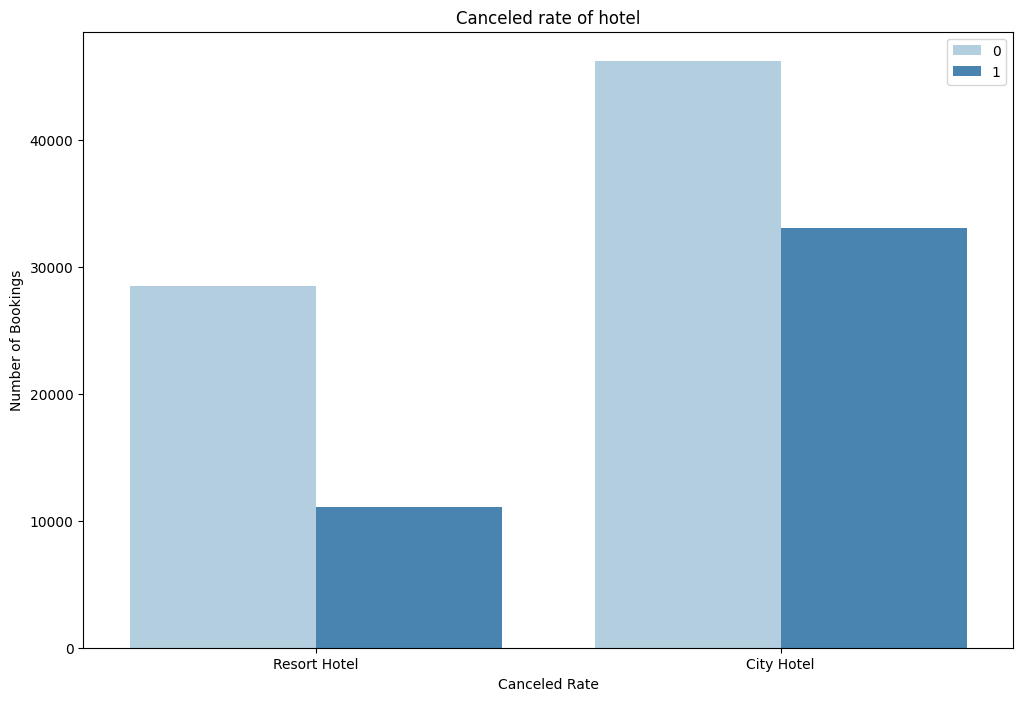

In [25]:
plt.figure(figsize=(12,8))
x1=sns.countplot(x='hotel',hue='is_canceled',data=df,palette='Blues')
x1.legend(bbox_to_anchor=(1,1))
plt.title('Canceled rate of hotel')
plt.xlabel('Canceled Rate')
plt.ylabel('Number of Bookings')
plt.show()

In [50]:
Resort_Hotel=df[df['hotel'] == 'Resort Hotel']
Resort_Hotel=Resort_Hotel.groupby('reservation_status_date')['adr'].mean()

In [51]:
City_hotel=df[df['hotel'] == 'City Hotel']
City_hotel=City_hotel.groupby('reservation_status_date')['adr'].mean()

### Comparison of Average Daily Rate (ADR) Between Resort and City Hotels

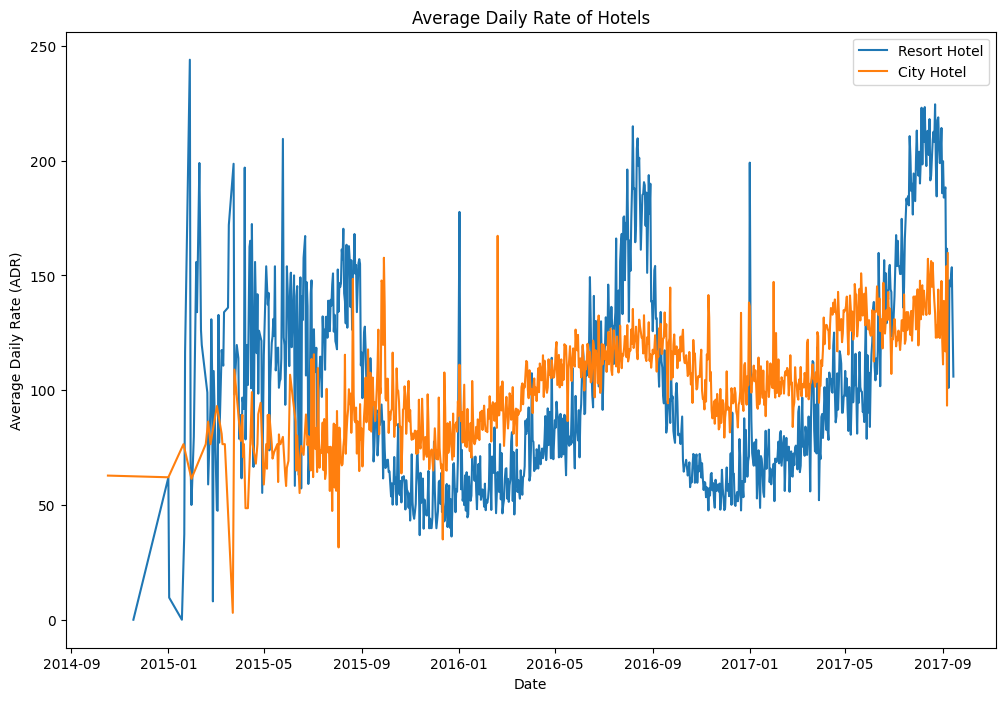

In [54]:
from ipywidgets import Label
plt.figure(figsize=(12,8))
plt.title("Average Daily Rate of Hotels")
plt.plot(Resort_Hotel.index, Resort_Hotel.values, label='Resort Hotel')
plt.plot(City_hotel.index, City_hotel.values, label='City Hotel')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Average Daily Rate (ADR)')
plt.show()

### Monthly Cancellation Rate Analysis

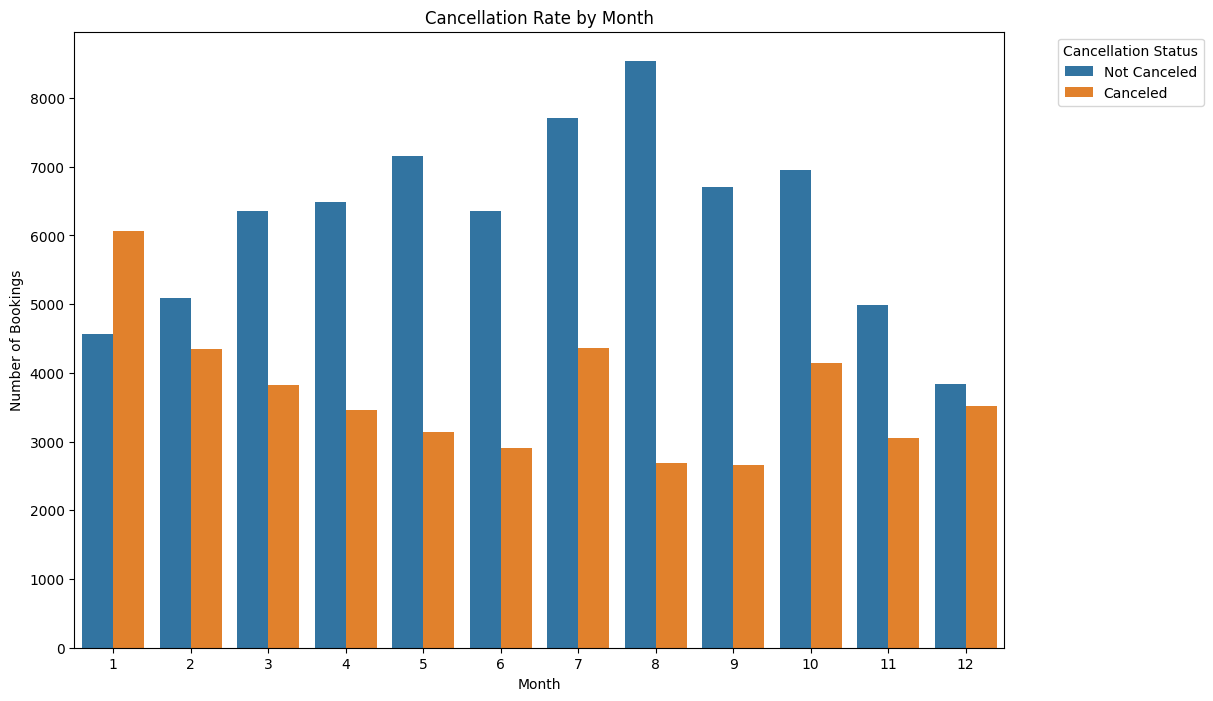

In [37]:
df['month']=df['reservation_status_date'].dt.month
plt.figure(figsize=(12,8))
ax = sns.countplot(x='month',hue='is_canceled',data=df)
ax.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Cancellation Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Bookings')
plt.show()

### Average Daily Rate (ADR) by Month

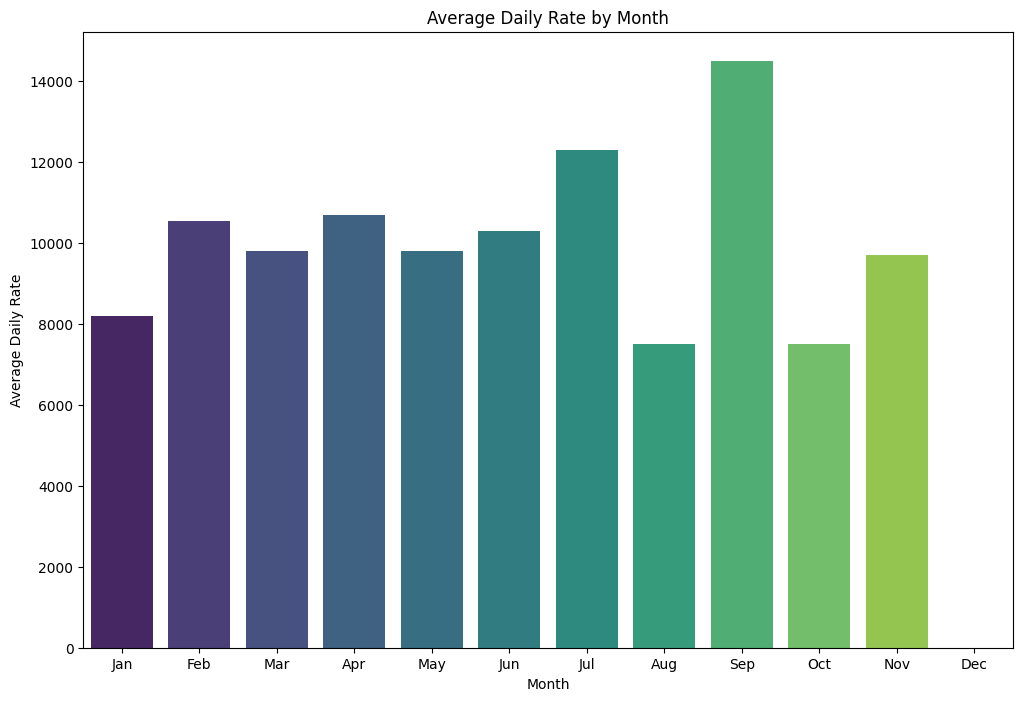

In [15]:
month_rate=df.groupby('month')['adr'].mean()*100
plt.figure(figsize=(12,8))
sns.barplot(x=month_rate.index, y=month_rate.values, palette='viridis')
plt.title("Average Daily Rate by Month")
plt.xlabel('Month')
month_name=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.ylabel('Average Daily Rate')
plt.xticks(ticks=range(12), labels=month_name)
plt.show()

### Top 10 Countries with Highest Cancellations

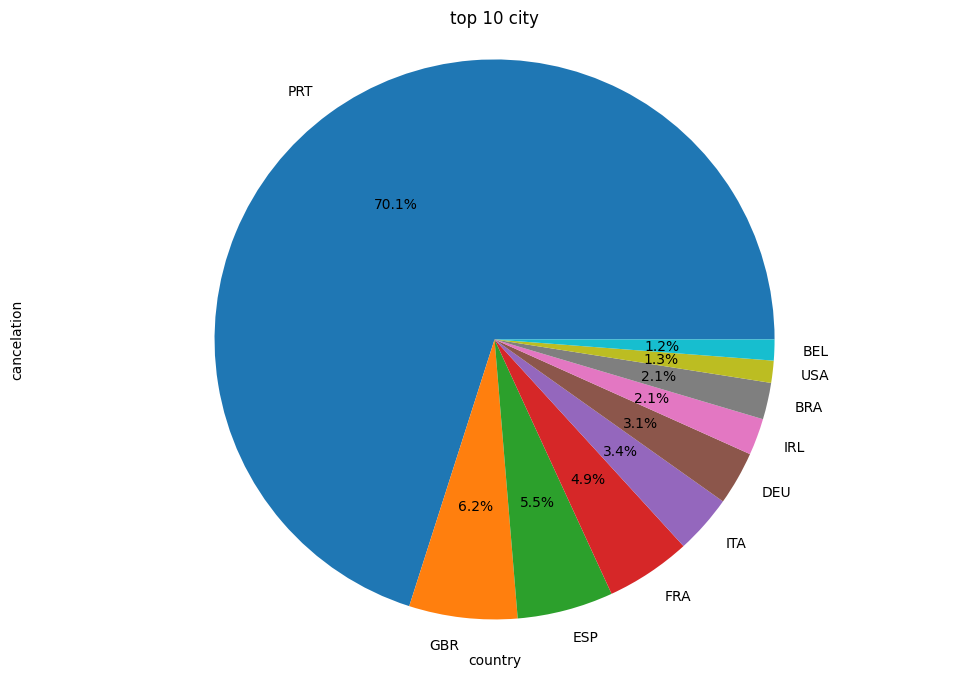

In [31]:
cancel=df[df['is_canceled'] == 1]
county_name=cancel['country'].value_counts().head(10)
plt.figure(figsize=(12,8))
plt.pie(county_name, labels=county_name.index,autopct='%1.1f%%')
plt.title('top 10 city')
plt.xlabel('country')
plt.ylabel('cancelation')
plt.axis('equal')
plt.show()

In [33]:
df['market_segment'].value_counts()

,proportion
market_segment,
Online TA,0.474373
Offline TA/TO,0.203199
Groups,0.166580
Direct,0.104695
Corporate,0.042986
Complementary,0.006173
Aviation,0.001993


In [34]:
df['market_segment'].value_counts(normalize=True)

,proportion
market_segment,
Online TA,0.474373
Offline TA/TO,0.203199
Groups,0.166580
Direct,0.104695
Corporate,0.042986
Complementary,0.006173
Aviation,0.001993


In [36]:
cancel['market_segment'].value_counts()

,count
market_segment,
Online TA,20738
Groups,12097
Offline TA/TO,8278
Direct,1920
Corporate,978
Complementary,90
Aviation,52


## Insights

- A significant number of hotel bookings are canceled, indicating a high cancellation rate
- Most cancellations are coming from specific countries
- City hotels tend to have higher cancellations compared to resort hotels
- Certain market segments contribute more to booking cancellations
- Booking and cancellation patterns vary across different months
- Average Daily Rate (ADR) changes over time and across months, showing pricing trends

## Conclusion

- Hotels should focus on reducing cancellation rates by improving booking policies
- Marketing strategies should target countries with higher booking potential
- Special attention should be given to customer segments with high cancellation rates
- Pricing strategies can be optimized based on monthly trends and demand
- Better planning and data-driven decisions can help increase overall revenue